In [1]:
# !pip install git+https://github.com/WorldCereal/prometheo.git@scaleag_augmentations --extra-index-url https://pypi.org/simple --timeout 60 --no-cache-dir
!pip install git+https://github.com/ScaleAGData/scaleag-vito.git@prometheo-integration --extra-index-url https://pypi.org/simple --timeout 60 --no-cache-dir


Looking in indexes: https://artifactory.vgt.vito.be/artifactory/api/pypi/python-packages/simple, https://pypi.org/simple
  Cloning https://github.com/ScaleAGData/scaleag-vito.git (to revision prometheo-integration) to /tmp/pip-req-build-1vlp7xi3
  Running command git clone --filter=blob:none --quiet https://github.com/ScaleAGData/scaleag-vito.git /tmp/pip-req-build-1vlp7xi3
  Running command git checkout -b prometheo-integration --track origin/prometheo-integration
  Switched to a new branch 'prometheo-integration'
  branch 'prometheo-integration' set up to track 'origin/prometheo-integration'.
  Resolved https://github.com/ScaleAGData/scaleag-vito.git to commit ad1c0b6f4d9125059574659f56b557d28a0f74c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/WorldCereal/prometheo.git to /tmp/pip-install-6ph9a24z/prometheo_0e481f223d7a44d3a3dd57e5d7640b8c
  Running command git clon

In [2]:
import prometheo.models.presto.wrapper as w
print(dir(w))

['ArrayTensor', 'BANDS', 'BANDS_ADD', 'BANDS_DIV', 'BANDS_GROUPS_IDX', 'DEM_BANDS', 'FinetuningHead', 'Literal', 'METEO_BANDS', 'NODATAVALUE', 'NUM_DYNAMIC_WORLD_CLASSES', 'Optional', 'Path', 'Predictors', 'Presto', 'PretrainedPrestoWrapper', 'S1_BANDS', 'S2_BANDS', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'calculate_ndvi', 'dataset_to_model', 'default_model_path', 'device', 'get_sinusoid_encoding_table', 'io', 'load_presto_weights', 'lru_cache', 'mapper', 'nn', 'normalize', 'np', 'rearrange', 'repeat', 'requests', 'to_torchtensor', 'torch', 'warnings']


In [2]:
from loguru import logger
import geopandas as gpd
from pathlib import Path
from scaleagdata_vito.openeo.extract_sample_scaleag import (
    generate_input_for_extractions,
    extract
)
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model
from prometheo.datasets.scaleag import ScaleAgDataset
from prometheo import finetune
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import PretrainedPrestoWrapper, load_pretrained
from torch import nn
from torch.optim import AdamW, lr_scheduler
from torch.utils.data import DataLoader
from scaleagdata_vito.presto.utils import evaluate_downstream_model, get_encodings
import catboost as cb

ImportError: cannot import name 'load_presto_weights' from 'prometheo.models.presto.wrapper' (/opt/conda/envs/python3/lib/python3.11/site-packages/prometheo/models/presto/wrapper.py)

In [1]:
from loguru import logger
import geopandas as gpd
from pathlib import Path

# scaleag-vito package imports
from scaleagdata_vito.openeo.extract_sample_scaleag import (
    generate_input_for_extractions,
    extract
)
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, evaluate_downstream_model, get_encodings

# # prometheo package imports
# from prometheo.datasets.scaleag import ScaleAgDataset
# from prometheo import finetune
# from prometheo.finetune import Hyperparams
# from prometheo.models.presto import param_groups_lrd
# from prometheo.models.presto.wrapper import PretrainedPrestoWrapper, load_pretrained  # ✅ fixed here

# # torch imports
# from torch import nn
# from torch.optim import AdamW, lr_scheduler
# from torch.utils.data import DataLoader

# # other ML imports
# import catboost as CB


ImportError: cannot import name 'load_presto_weights' from 'prometheo.models.presto.wrapper' (/opt/conda/envs/python3/lib/python3.11/site-packages/prometheo/models/presto/wrapper.py)

In [2]:
# !pip install --upgrade prometheo

In [3]:
# from prometheo.models.presto.wrapper import

In [4]:
!pip uninstall -y prometheo

Found existing installation: prometheo 0.0.1
Uninstalling prometheo-0.0.1:
  Successfully uninstalled prometheo-0.0.1


### install the latest master/main branch directly from GitHub using pip

* https://github.com/WorldCereal/prometheo/blob/main/prometheo/models/presto/wrapper.py

In [5]:
!pip install git+https://github.com/WorldCereal/prometheo.git@main --no-cache-dir --timeout 60


Looking in indexes: https://artifactory.vgt.vito.be/artifactory/api/pypi/python-packages/simple
  Cloning https://github.com/WorldCereal/prometheo.git (to revision main) to /tmp/pip-req-build-rkknrhit
  Running command git clone --filter=blob:none --quiet https://github.com/WorldCereal/prometheo.git /tmp/pip-req-build-rkknrhit
  Resolved https://github.com/WorldCereal/prometheo.git to commit 99b7bbd1bf6d3d68d0be36550c8bab94a890ff19
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for prometheo: filename=prometheo-0.0.1-py3-none-any.whl size=28384 sha256=3737453ee18bbfb5940ed38884fd1a8af793ebb481c118c5edb857bba18e6bcf
  Stored in directory: /tmp/pip-ephem-wheel-cache-hsq6kwv3/wheels/4f/0a/43/15e8387b2b4263247549d18c7e0f0e5ed4c1f0799bdc7d7ea3
Successfully built prometheo


In [5]:
from prometheo.models.presto.wrapper import load_presto_weights

In [6]:
from loguru import logger
import geopandas as gpd
from pathlib import Path

# scaleag-vito package imports
from scaleagdata_vito.openeo.extract_sample_scaleag import (
    generate_input_for_extractions,
    extract
)
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, evaluate_downstream_model, get_encodings

# prometheo package imports
from prometheo.datasets.scaleag import ScaleAgDataset
from prometheo import finetune
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import PretrainedPrestoWrapper, load_pretrained 
# torch imports
from torch import nn
from torch.optim import AdamW, lr_scheduler
from torch.utils.data import DataLoader

# other ML imports
import catboost as CB


ImportError: cannot import name 'load_pretrained' from 'prometheo.models.presto.wrapper' (/opt/conda/envs/python3/lib/python3.11/site-packages/prometheo/models/presto/wrapper.py)

In [8]:
###  Run modules

In [7]:
from loguru import logger
import geopandas as gpd
from pathlib import Path

# scaleag-vito package imports
from scaleagdata_vito.openeo.extract_sample_scaleag import (
    generate_input_for_extractions,
    extract
)
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, evaluate_downstream_model, get_encodings

# prometheo package imports
from prometheo.datasets.scaleag import ScaleAgDataset
from prometheo import finetune
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import PretrainedPrestoWrapper  # load_presto_weights is manually defined

# torch imports
from torch import nn
from torch.optim import AdamW, lr_scheduler
from torch.utils.data import DataLoader

# other ML imports
import catboost as CB


In [9]:
def check_unique_id(df_path, unique_id):
    df = gpd.read_file(df_path)
    if df[unique_id].nunique() != df.shape[0]:
        logger.info("IDs are not unique!")
        return df[df[unique_id].duplicated(keep=False)]
    else:
        logger.info("IDs are unique")
        return None

def check_valid_geometry(df):
    if isinstance(df, str):
        df = gpd.read_file(df)
    df_invalid = df[~df.geometry.is_valid]
    # Assessing wheather some invalid geometries are present
    if len(df_invalid) > 0:
        # 1) some invalid geometries are present. Attempt fixing them
        df['geometry'] = df.geometry.buffer(0)
        df_invalid = df[~df.geometry.is_valid]
        df_valid = df[df.geometry.is_valid]
        if len(df_invalid) > 0:
            # 2) Still some invalid geometries are present. Return them
            logger.info("Invalid geometries found! Returning invalid geometries")
            return df_invalid, df_valid
        else:
            # All geometries are now valid. Return fixed dataframe and empty dataframe for invalid geometries
            logger.info("Fixed some invalid geometries. All geometries are now valid")
            return gpd.GeoDataFrame(), df
    else:
        # All geometries are valid. Return empty dataframe for invalid geometries
        logger.info("All geometries are valid")
        return gpd.GeoDataFrame(), df

def _save(save_to, original_file_path, df, suffix=''):
    if suffix!='':
        filename = Path(save_to) / f"{Path(original_file_path).stem}_{suffix}.geojson"
    else:
        filename = Path(save_to) / f"{Path(original_file_path).stem}.geojson"
    logger.info(f"Saving invalid geometries to {filename}")
    Path(save_to).mkdir(parents=True, exist_ok=True)
    df.to_file(filename)

In [10]:
input_file = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
invalid_geom, valid_geom = check_valid_geometry(input_file)
non_unique_ids = check_unique_id(input_file, unique_id="Field_id")

2025-06-05 09:03:45.926 | INFO     | __main__:check_valid_geometry:30 - All geometries are valid
2025-06-05 09:03:45.960 | INFO     | __main__:check_unique_id:7 - IDs are unique


In [10]:
!pwd

/home/theonarh/GEOMaize.git/notebooks


In [13]:
!ls /home/theonarh/GEOMaize.git/data

README.md  correct


In [15]:
# # save files after geometry validity check. If invalid geometries are present, save them to a separate file
# if len(invalid_geom) > 0:
#     _save(
#         save_to="/home/giorgia/Private/data/geomaize/invalid/",
#         original_file_path=input_file,
#         df=invalid_geom,
#         suffix='',
#     )

# # save valid geometries to a separate file
# _save(
#     save_to="/home/giorgia/Private/data/geomaize/correct/",
#     original_file_path=input_file,
#     df=valid_geom,
#     suffix='',
# )

In [17]:
from pathlib import Path
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(f"{outdir}")
output_path.mkdir(parents=True, exist_ok=True)


# Dataset Parameters
task_type = "regression"
start_date="2021-07-01"
end_date="2021-10-31"
composite_window="dekad"
unique_id_column="Field_id"
input_df=f"{input_file}"
output_folder=f"{outdir}"

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)
extract(generate_input_for_extractions(job_params))

2025-06-04 21:57:05,476|extraction_pipeline|INFO:  Loading input dataframe from /home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson.
2025-06-04 21:57:05,512|extraction_pipeline|INFO:  Setting up the extraction functions.
2025-06-04 21:57:05,513|extraction_pipeline|INFO:  Initializing the job manager.
2025-06-04 21:57:05,513|extraction_pipeline|INFO:  Launching the jobs manager.
2025-06-04 21:57:05,513|openeo_gfmap.manager|INFO:  Starting ThreadPoolExecutor with 4 workers.
2025-06-04 21:57:05,514|openeo_gfmap.manager|INFO:  Creating and running jobs.


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=ZRSO-FZLZ 📋 to authenticate.

❌ Timed out

2025-06-04 21:57:37,147|extraction_pipeline|ERROR:  An unexpected error occurred during the extraction.
Timeout (30.0s) while polling for access token.
Traceback (most recent call last):
  File "/opt/conda/envs/python3/lib/python3.11/site-packages/scaleagdata_vito/openeo/extract_sample_scaleag.py", line 427, in manager_main_loop
    manager.run_jobs(job_df, datacube_fn, tracking_df_path)
  File "/opt/conda/envs/python3/lib/python3.11/site-packages/openeo_gfmap/manager/job_manager.py", line 558, in run_jobs
    super().run_jobs(df, start_job, output_file)
  File "/opt/conda/envs/python3/lib/python3.11/site-packages/openeo/extra/job_management.py", line 504, in run_jobs
    self._job_update_loop(job_db=job_db, start_job=start_job, stats=stats)
  File "/opt/conda/envs/python3/lib/python3.11/site-packages/openeo/extra/job_management.py", line 544, in _job_update_loop
    self._launch_job(start_job, df=not_started, i=i, backend_name=backend_name, stats=stats)
  File "/opt/conda/envs/python3

OidcDeviceCodePollTimeout: Timeout (30.0s) while polling for access token.

In [12]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
import logging

# === Setup logging (optional) ===
logging.basicConfig(level=logging.INFO)

# === Step 1: Ensure output directory exists ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Step 2: Authenticate with OpenEO CDSE (with extended timeout) ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# Optional: Save connection to use inside the extraction module if needed
# For some wrappers you may need to inject this into the job manager directly

# === Step 3: Define extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Step 4: Run the extraction ===
extract(generate_input_for_extractions(job_params))


INFO:openeo.config:Loaded openEO client config from sources: []
INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-05 09:05:56,4

Authenticated using refresh token.


In [13]:
train_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2021"
valid_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2022"
test_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2023"

train_df = load_dataset(
    train_path,
    composite_window=composite_window
    )

val_df = load_dataset(
    valid_path,
    composite_window=composite_window
    )

test_df = load_dataset(
    test_path,
    composite_window=composite_window
    )

0it [00:00, ?it/s]


ValueError: No objects to concatenate

In [15]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
from scaleagdata_vito.presto.presto_df import load_dataset
import logging
import pandas as pd

# === Setup logging ===
logging.basicConfig(level=logging.INFO)

# === Output path setup ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Authenticate OpenEO ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# === Extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Run the extraction ===
extract(generate_input_for_extractions(job_params))

# === Debug output directory ===
print(f"\n🔍 Listing contents of {outdir} ...")
files = list(output_path.glob("**/*"))
for f in files:
    print(f"- {f.relative_to(output_path)}")

# === Load dataset only if parquet files exist ===
def safe_load_dataset(path, composite_window):
    parquet_files = list(Path(path).rglob("*.parquet"))
    if not parquet_files:
        print(f"\n⚠️ No .parquet files found in: {path}")
        return None
    return load_dataset(path, composite_window=composite_window)

df = safe_load_dataset(outdir, composite_window)

if df is not None:
    print(f"\n✅ Dataset loaded successfully with shape: {df.shape}")
else:
    print("\n❌ Dataset not loaded. Ensure that .parquet files were generated.")


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-05 09:17:25,912|extraction_pipeline|INFO:  Loading input dataframe from /home

Authenticated using refresh token.

🔍 Listing contents of /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/ ...
- job_tracking.csv
- failed_jobs
- 30
- failed_jobs/ScaleAgData_Geometry_Extraction_30PYR_j-25060422081644cc905d8161d0534224.log
- 30/30PYR
- 30/30PZR
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
- 30/30PZR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PZR_j-2506042218404a769076bbb82d654a86.geoparquet

⚠️ No .parquet files found in: /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/

❌ Dataset not loaded. Ensure that .parquet files were generated.


In [16]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
from scaleagdata_vito.presto.presto_df import load_dataset
import logging
import pandas as pd

# === Setup logging ===
logging.basicConfig(level=logging.INFO)

# === Output path setup ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Authenticate OpenEO ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# === Extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Run the extraction ===
extract(generate_input_for_extractions(job_params))

# === Debug output directory ===
print(f"\n🔍 Listing contents of {outdir} ...")
files = list(output_path.glob("**/*"))
for f in files:
    print(f"- {f.relative_to(output_path)}")

# === Load geoparquet files ===
def safe_load_geoparquet_dataset(path):
    geo_files = list(Path(path).rglob("*.geoparquet"))
    if not geo_files:
        print(f"\n No .geoparquet files found in: {path}")
        return None
    # Concatenate all geoparquet files
    dfs = [pd.read_parquet(fp) for fp in geo_files]
    return pd.concat(dfs, ignore_index=True)

df = safe_load_geoparquet_dataset(outdir)

if df is not None:
    print(f"\n Dataset loaded successfully with shape: {df.shape}")
else:
    print("\n Dataset not loaded. Ensure that .geoparquet files were generated.")


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-05 09:18:31,104|extraction_pipeline|INFO:  Loading input dataframe from /home

Authenticated using refresh token.

🔍 Listing contents of /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/ ...
- job_tracking.csv
- failed_jobs
- 30
- failed_jobs/ScaleAgData_Geometry_Extraction_30PYR_j-25060422081644cc905d8161d0534224.log
- 30/30PYR
- 30/30PZR
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
- 30/30PZR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PZR_j-2506042218404a769076bbb82d654a86.geoparquet

✅ Dataset loaded successfully with shape: (1596, 33)


In [18]:
df.head()

,feature_index,S2-L2A-B02,S2-L2A-B03,S2-L2A-B04,S2-L2A-B05,S2-L2A-B06,S2-L2A-B07,S2-L2A-B08,S2-L2A-B8A,S2-L2A-B11,...,Crop,Type,COMMUNITY,Year,tile,Field_id,Season,lat,start_date,timestamp
0,0,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4009CHA,July-October,9.218397,2021-07-01,2021-09-01 00:00:00+00:00
1,1,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4047CHA,July-October,9.218051,2021-07-01,2021-09-01 00:00:00+00:00
2,2,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4051CHA,July-October,9.220596,2021-07-01,2021-09-01 00:00:00+00:00
3,3,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4050CHA,July-October,9.218463,2021-07-01,2021-09-01 00:00:00+00:00
4,4,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4048CHA,July-October,9.219466,2021-07-01,2021-09-01 00:00:00+00:00


In [22]:
df.columns

Index(['feature_index', 'S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
       'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A', 'S2-L2A-B11',
       'S2-L2A-B12', 'S1-SIGMA0-VH', 'S1-SIGMA0-VV', 'slope', 'elevation',
       'AGERA5-PRECIP', 'AGERA5-TMEAN', 'geometry', 'Area(acre)', 'end_date',
       'sample_id', 'lon', 'REGION', 'Crop', 'Type', 'COMMUNITY', 'Year',
       'tile', 'Field_id', 'Season', 'lat', 'start_date', 'timestamp'],
      dtype='object')

In [19]:
from pathlib import Path
import openeo
from scaleagdata_vito.openeo.extract_sample_scaleag import extract, generate_input_for_extractions
import geopandas as gpd
import logging

# === Setup logging ===
logging.basicConfig(level=logging.INFO)

# === Output path setup ===
outdir = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/"
output_path = Path(outdir)
output_path.mkdir(parents=True, exist_ok=True)

# === Authenticate OpenEO ===
conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc(max_poll_time=300)  # 5 minutes timeout

# === Extraction parameters ===
task_type = "regression"
start_date = "2021-07-01"
end_date = "2021-10-31"
composite_window = "dekad"
unique_id_column = "Field_id"
input_df = "/home/theonarh/GEOMaize.git/data/correct/Maize_North_Ghana_valid.geojson"
output_folder = outdir

job_params = dict(
    output_folder=output_folder,
    input_df=input_df,
    start_date=start_date,
    end_date=end_date,
    unique_id_column=unique_id_column,
    composite_window=composite_window,
)

# === Run the extraction ===
extract(generate_input_for_extractions(job_params))

# === Debug: list contents ===
print(f"\n🔍 Listing contents of {outdir} ...")
files = list(output_path.glob("**/*"))
for f in files:
    print(f"- {f.relative_to(output_path)}")

# === Load .geoparquet files into GeoDataFrame ===
def load_geoparquet_as_gdf(path):
    geo_files = list(Path(path).rglob("*.geoparquet"))
    if not geo_files:
        print(f"\n No .geoparquet files found in: {path}")
        return None
    # Load and concatenate all files as GeoDataFrames
    gdfs = [gpd.read_parquet(fp) for fp in geo_files]
    return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

gdf = load_geoparquet_as_gdf(outdir)

# === Check result ===
if gdf is not None:
    print(f"\n✅ GeoDataFrame loaded successfully with shape: {gdf.shape}")
    print(f"📌 CRS: {gdf.crs}")
else:
    print("\n❌ GeoDataFrame not loaded. Ensure that .geoparquet files were generated.")


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2025-06-05 09:41:55,990|extraction_pipeline|INFO:  Loading input dataframe from /home

Authenticated using refresh token.

🔍 Listing contents of /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/ ...
- job_tracking.csv
- failed_jobs
- 30
- failed_jobs/ScaleAgData_Geometry_Extraction_30PYR_j-25060422081644cc905d8161d0534224.log
- 30/30PYR
- 30/30PZR
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
- 30/30PYR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
- 30/30PZR/SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PZR_j-2506042218404a769076bbb82d654a86.geoparquet

✅ GeoDataFrame loaded successfully with shape: (1596, 33)
📌 CRS: {"$schema": "https://proj.org/schemas/v0.6/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": 

In [20]:
gdf.head()

,feature_index,S2-L2A-B02,S2-L2A-B03,S2-L2A-B04,S2-L2A-B05,S2-L2A-B06,S2-L2A-B07,S2-L2A-B08,S2-L2A-B8A,S2-L2A-B11,...,Crop,Type,COMMUNITY,Year,tile,Field_id,Season,lat,start_date,timestamp
0,0,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4009CHA,July-October,9.218397,2021-07-01,2021-09-01 00:00:00+00:00
1,1,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4047CHA,July-October,9.218051,2021-07-01,2021-09-01 00:00:00+00:00
2,2,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4051CHA,July-October,9.220596,2021-07-01,2021-09-01 00:00:00+00:00
3,3,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4050CHA,July-October,9.218463,2021-07-01,2021-09-01 00:00:00+00:00
4,4,65535,65535,65535,65535,65535,65535,65535,65535,65535,...,Maize,Mono Cropping,Chambuligu,2021,30PYR,4048CHA,July-October,9.219466,2021-07-01,2021-09-01 00:00:00+00:00


In [21]:
gdf.columns

Index(['feature_index', 'S2-L2A-B02', 'S2-L2A-B03', 'S2-L2A-B04', 'S2-L2A-B05',
       'S2-L2A-B06', 'S2-L2A-B07', 'S2-L2A-B08', 'S2-L2A-B8A', 'S2-L2A-B11',
       'S2-L2A-B12', 'S1-SIGMA0-VH', 'S1-SIGMA0-VV', 'slope', 'elevation',
       'AGERA5-PRECIP', 'AGERA5-TMEAN', 'geometry', 'Area(acre)', 'end_date',
       'sample_id', 'lon', 'REGION', 'Crop', 'Type', 'COMMUNITY', 'Year',
       'tile', 'Field_id', 'Season', 'lat', 'start_date', 'timestamp'],
      dtype='object')

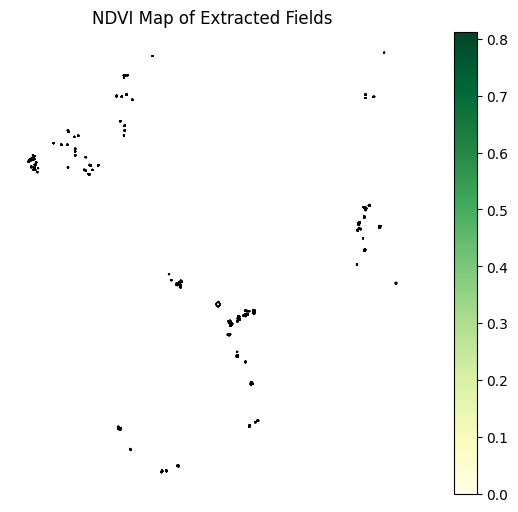

In [24]:
import matplotlib.pyplot as plt
# Compute NDVI from Sentinel-2 bands
gdf["NDVI"] = (gdf["S2-L2A-B08"] - gdf["S2-L2A-B04"]) / (gdf["S2-L2A-B08"] + gdf["S2-L2A-B04"])
df['NDVI'] = (df['S2-L2A-B08'] - df['S2-L2A-B04']) / (df['S2-L2A-B08'] + df['S2-L2A-B04'] + 1e-10)

# Plot NDVI spatially
gdf.plot(column="NDVI", cmap="YlGn", legend=True, figsize=(10, 6), edgecolor='black')
plt.title("NDVI Map of Extracted Fields")
plt.axis('off')
plt.show()


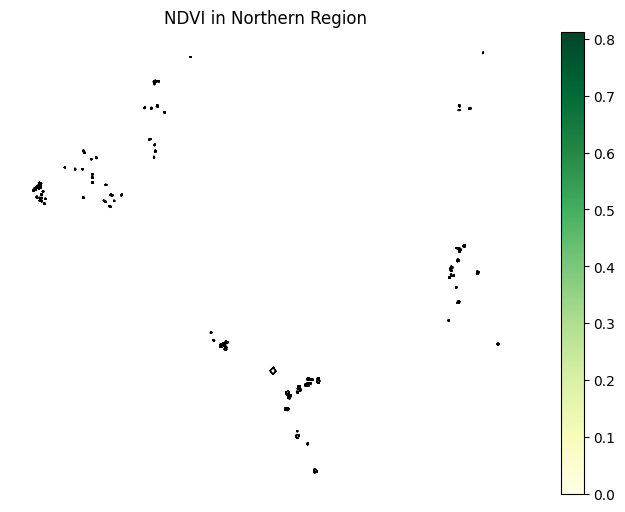

In [25]:
# Clip to a specific region
northern_gdf = gdf[gdf["REGION"].str.upper().str.contains("NORTH")]

# Plot the clipped region
northern_gdf.plot(column="NDVI", cmap="YlGn", legend=True, figsize=(10, 6), edgecolor='black')
plt.title("NDVI in Northern Region")
plt.axis('off')
plt.show()


In [26]:
avg_ndvi_per_crop = gdf.groupby("Crop")["NDVI"].mean().sort_values(ascending=False)
print(avg_ndvi_per_crop)


Crop
maize    0.161467
Maize    0.139275
Name: NDVI, dtype: float64


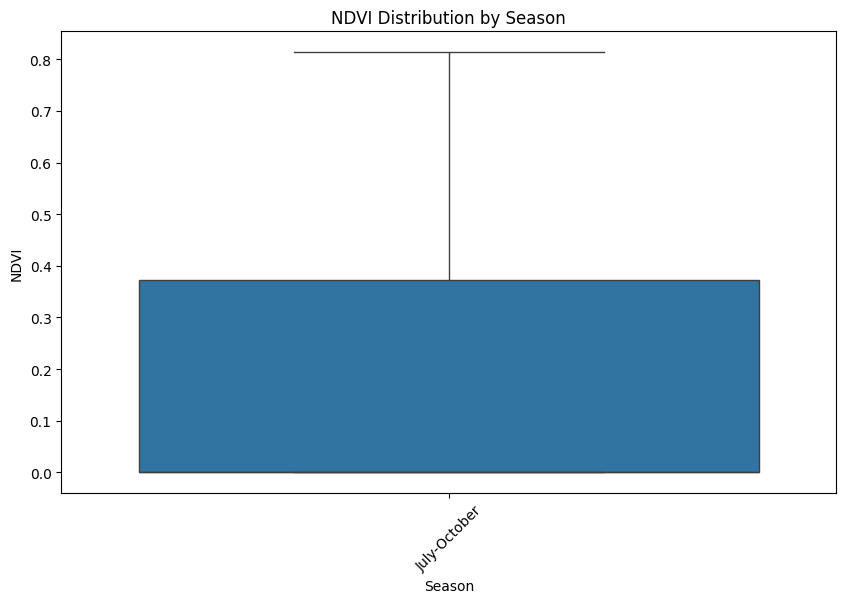

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=gdf, x="Season", y="NDVI")
plt.title("NDVI Distribution by Season")
plt.xticks(rotation=45)
plt.show()


In [28]:
train_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2021"
valid_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2022"
test_path = "/home/theonarh/GEOMaize.git/data/geomaize/extractions_2023"

train_df = load_dataset(
    train_path,
    composite_window=composite_window
    )

val_df = load_dataset(
    valid_path,
    composite_window=composite_window
    )

test_df = load_dataset(
    test_path,
    composite_window=composite_window
    )

0it [00:00, ?it/s]


ValueError: No objects to concatenate

In [29]:
!pwd

/home/theonarh/GEOMaize.git/notebooks


In [33]:
!ls /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/30

30PYR  30PZR


In [34]:
!ls /home/theonarh/GEOMaize.git/data/geomaize/extractions_North_Ghana/30/30PYR

SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042208354b93a1ce9ad48d53d700.geoparquet
SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042210554ce8a6535b3426047052.geoparquet
SCALEAG_extractions_North_Ghana_2021-07-01_2021-10-31_30PYR_j-2506042214184da28b700138f1e3d01b.geoparquet
